In [ ]:
%pip install puremacro


# Aiyagari con Oferta Laboral Endógena — Mercados Incompletos en Equilibrio General

**¿Cómo interactúa la oferta laboral endógena con el ahorro precautorio cuando los hogares ajustan tanto el ahorro como las horas de trabajo?** En el modelo base de Aiyagari (1994), la oferta laboral es inelástica ($h=1$), por lo que los choques de productividad idiosincrásicos se traducen directamente en riesgo de ingreso. Cuando los hogares pueden ajustar sus horas de trabajo $h(a, z)$, los hogares con poca riqueza trabajan más para autoasegurarse contra choques desfavorables (un efecto riqueza negativo en la oferta laboral), mientras que los hogares de alta riqueza consumen más ocio. Este cuaderno resuelve el **modelo de equilibrio general de Aiyagari con oferta laboral endógena** usando `puremacro.vfi.aiyagari_endogenous.solve_aiyagari_endogenous`, demostrando el vaciado de mercado en capital ($K$) y trabajo ($L$).

## El método en matemáticas — Elección Laboral Intratemporal y Vaciado de Mercado en EG

Los hogares resuelven:
$$ V(a, z) = \max_{a' \ge 0, h \in [0, 1]} \left\{ \frac{c^{1-\sigma}}{1-\sigma} - \chi \frac{h^{1+1/\nu}}{1+1/\nu} + \beta \sum_{z'} P(z, z') V(a', z') \right\} $$
sujeto a:
$$ c + a' = (1+r)a + w \cdot z \cdot h $$
La tecnología Cobb-Douglas de las firmas $Y = A K^\alpha L^{1-\alpha}$ determina los precios de los factores:
$$ r = \alpha A (K/L)^{\alpha - 1} - \delta, \qquad w = (1-\alpha) A (K/L)^\alpha $$
**Equilibrio General.** Un equilibrio estacionario requiere precios de factores $(r^*, w^*)$ tales que la demanda agregada de capital sea igual a los tenencias de activos agregadas de los hogares $K = \int a \, d\mu(a, z)$ y la demanda agregada de trabajo sea igual a la oferta agregada de trabajo $L = \int z \cdot h(a, z) d\mu(a, z)$.

## Configuración — resolviendo el modelo de trabajo endógeno en EG

Resolvemos los precios de factores de equilibrio $(r^*, w^*)$, las funciones de política óptimas $a'(a, z)$ y $h(a, z)$, y las cantidades agregadas $(K^*, L^*)$.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi.aiyagari_endogenous import solve_aiyagari_endogenous

# Resolver EG de Aiyagari con oferta laboral endógena
results = solve_aiyagari_endogenous(
    beta=0.95,
    gamma=2.0,
    frisch=0.5,
    chi=1.2,
    alpha=0.36,
    delta=0.08,
    rho_e=0.90,
    sigma_e=0.20,
    Na=150,
    Ne=21,
    r_guess=0.035
)

r_star = results["r_star"]
w_star = results["w_star"]
K_star = results["K_star"]
L_star = results["L_star"]
grid_a = results["a_grid"]
e_grid = results["e_grid"]
policy_n = results["policy_n"] # Política laboral: forma (Na, Ne)
policy_a = results["policy_a"]

print(f"Tasa de Interés Neta de Equilibrio r*: {r_star:.4f}")
print(f"Tasa de Salario de Equilibrio w*: {w_star:.4f}")
print(f"Capital Agregado K*: {K_star:.4f}")
print(f"Trabajo Agregado L*: {L_star:.4f}")
print(f"Razón Capital-Trabajo K/L: {(K_star / L_star):.4f}")
print(f"Vaciado del mercado |K - K_demanda| / K: {abs(results['excess_demand']) / K_star:.2e}"
      f"  ({results['n_evals']} soluciones del hogar)")

# Afirmaciones clave
assert r_star < 1/0.95 - 1.0, f"r* debe estar estrictamente por debajo de 1/beta - 1: {r_star}"
assert K_star > 0.0 and L_star > 0.0, "Los factores agregados deben ser positivos"
assert policy_n.shape == (150, 21), "Discrepancia en la forma de la política laboral"

Tasa de Interés Neta de Equilibrio r*: 0.0331
Tasa de Salario de Equilibrio w*: 1.2277
Capital Agregado K*: 5.2373
Trabajo Agregado L*: 0.8575
Razón Capital-Trabajo K/L: 6.1079
Vaciado del mercado |K - K_demanda| / K: 1.13e-06  (13 soluciones del hogar)


## Figura Principal — Reglas de política de oferta laboral endógena n(a, e)

Graficamos la oferta laboral óptima $n(a, e)$ a través de los niveles de riqueza $a$ para diferentes estados de productividad $e$.

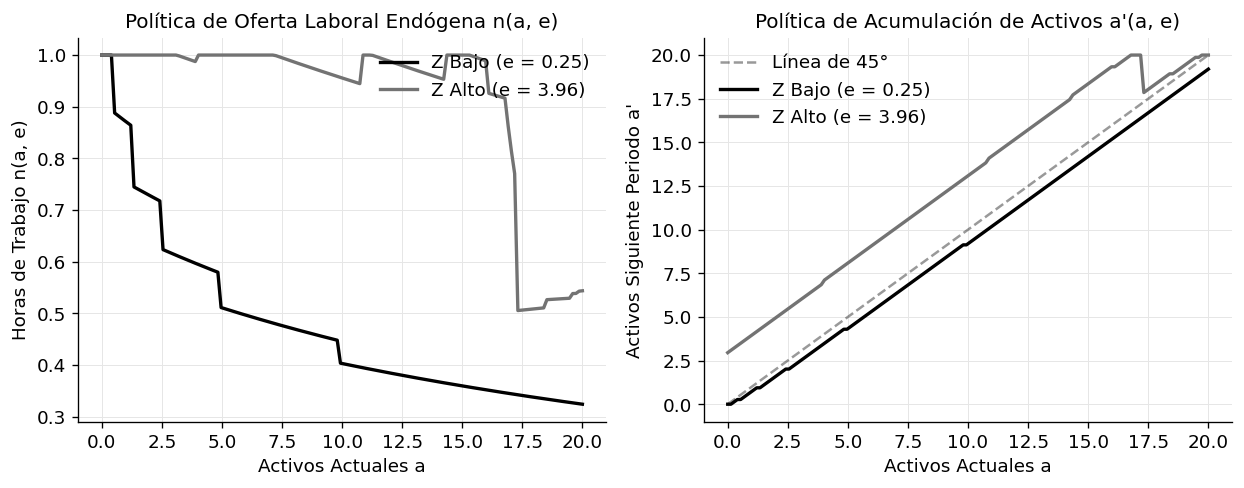

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# Panel Izquierdo: Política laboral endógena n(a, e)
ax1.plot(grid_a, policy_n[:, 0], color=_nbstyle.palette(2)[0], lw=2, label=f"Z Bajo (e = {e_grid[0]:.2f})")
ax1.plot(grid_a, policy_n[:, -1], color=_nbstyle.palette(2)[1], lw=2, label=f"Z Alto (e = {e_grid[-1]:.2f})")
ax1.set_xlabel("Activos Actuales a")
ax1.set_ylabel("Horas de Trabajo n(a, e)")
ax1.set_title("Política de Oferta Laboral Endógena n(a, e)")
ax1.legend(loc="upper right")

# Panel Derecho: Política de activos a'(a, e)
ax1_line = np.linspace(0, grid_a[-1], 100)
ax2.plot(ax1_line, ax1_line, "k--", alpha=0.4, label="Línea de 45°")
ax2.plot(grid_a, policy_a[:, 0], color=_nbstyle.palette(2)[0], lw=2, label=f"Z Bajo (e = {e_grid[0]:.2f})")
ax2.plot(grid_a, policy_a[:, -1], color=_nbstyle.palette(2)[1], lw=2, label=f"Z Alto (e = {e_grid[-1]:.2f})")
ax2.set_xlabel("Activos Actuales a")
ax2.set_ylabel("Activos Siguiente Periodo a'")
ax2.set_title("Política de Acumulación de Activos a'(a, e)")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Leyendo el resultado.** Las horas de trabajo $n(a, e)$ disminuyen con la riqueza $a$ debido al efecto riqueza negativo: los hogares más pobres trabajan más horas para amortiguar el riesgo de ingresos, mientras que los hogares más ricos eligen ocio. Una productividad más alta eleva las horas en promedio, por el efecto sustitución de un salario mayor — aunque no en todos los puntos: en la parte baja de la malla de riqueza los hogares menos productivos quedan contra la dotación de tiempo $n \le 1$, y como $n$ se lee en el $a'$ elegido, que es un índice de malla, la política hereda esa discretización.

## Tu turno — elasticidad de Frisch y capacidad de respuesta del mercado laboral

**Ejercicios.**
1. *Básico*: Incrementa la elasticidad de Frisch de `frisch = 0.5` a `frisch = 0.8` (`# ← cambia esto ...`). ¿Se vuelve la oferta laboral más sensible a los niveles de riqueza?
2. *Intermedio*: Incrementa el parámetro de desutilidad del trabajo `chi = 2.0` y observa la disminución en la oferta laboral agregada $L^*$.
3. *Avanzado*: Compara el capital agregado $K^*$ entre menor y mayor elasticidad de la oferta laboral.

In [3]:
# Bloque de código Tu turno
frisch_yt = 0.8  # ← cambia esto: prueba 0.8 o 1.0

res_yt = solve_aiyagari_endogenous(
    beta=0.95,
    gamma=2.0,
    frisch=frisch_yt,
    chi=1.2,
    alpha=0.36,
    delta=0.08,
    rho_e=0.90,
    sigma_e=0.20,
    Na=150,
    Ne=21
)

print(f"Nueva Elasticidad de Frisch frisch = {frisch_yt:.2f}")
print(f"Nuevo r* de Equilibrio: {res_yt['r_star']:.4f}")
print(f"Nuevo Trabajo Agregado L*: {res_yt['L_star']:.4f}")

# Afirmación válida para el valor por defecto
assert res_yt["K_star"] > 0.0, "El capital agregado debe ser positivo"

Nueva Elasticidad de Frisch frisch = 0.80
Nuevo r* de Equilibrio: 0.0313
Nuevo Trabajo Agregado L*: 0.8284


## ¿Qué tan exhaustivo es esto?

`puremacro.vfi.aiyagari_endogenous` proporciona el resolvedor de mercados incompletos de EG con optimización laboral intratemporal flexible, conectándose directamente con modelos Nuevos Keynesianos de Agentes Heterogéneos (HANK) y rutinas de distribución en `puremacro.vfi`.